In [13]:
import math
from scipy import constants as const
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import numpy as np
from scipy.integrate import quad
import scipy as sp
import sympy as smp

# The Boltzmann Distribution

Calculates the speed and probability of copper electron escaping copper atom given temperature

In [5]:
k = const.k #Joules / Kelvin
T = 1000 #Kelvin
m_e = const.m_e #Kg
E = 5 #eV

E_j = (1.6e-19) * E #Energy in Joules
v_min = math.sqrt((2 * E_j)/m_e) # Minimum speed electron needs to escape copper atom

print(f"Minimum speed an electron needs to escape copper atom is roughly {v_min:.3e} m/s")

def Maxwell_Speed_Distribution(v, m, T):
    return 4*np.pi * (m/(2*np.pi*k*T))**(3/2) * v**2 * np.exp(-m*v**2/(2*k*T))

P = quad(Maxwell_Speed_Distribution, v_min, np.inf, args=(m_e, T))

print(f"Probability an electron having enough energy to escape is {P[0]:0.3e}")

Minimum speed an electron needs to escape copper atom is roughly 1.325e+06 m/s
Probability an electron having enough energy to escape is 6.920e-26



Maxwell's speed distribution for Air Molecules

In [5]:
v_nm = 517 #Avergae velocity of nitrogen molecule in a typical room in m/s
m_nm = 4.65e-26 #mass of nitrogen molecule in Kg
T_room = 300 #Room temperature in Kelvin

print(f"Probability nitrogen moleculeis within 50 m/s of is {quad(Maxwell_Speed_Distribution, v_nm - 50, v_nm + 50, args=(m_nm, T_room))[0]:0.3f}")
print(f"Probability a given molecule is more than twice the average speed is {quad(Maxwell_Speed_Distribution, 2 * v_nm, np.inf, args=(m_nm, T_room))[0]:0.3f}")

Probability nitrogen moleculeis within 50 m/s of is 0.178
Probability a given molecule is more than twice the average speed is 0.007


Calculates <E> given discrete energy levels. Enter how much each level increases by and how many energy levels you want

In [7]:
def E_av(levels, Delta_E):
    Z = 0.0
    for E in range(levels):
        Z += math.exp(-E * Delta_E)
    E_av = 0.0
    for E in range(levels):
        E_av += ((E * Delta_E) / Z) * math.exp(-E * Delta_E)
    return E_av
    
print(f"Average energy with 3 distinct energy levels differing by 3kT is {E_av(3, 3):0.3f}kT")
print(f"Average energy with 3 distinct energy levels differing by 6kT is {E_av(3, 6):0.3f}kT")
print(f"Average energy with 60 distinct energy levels differing by (1/10)kT is {E_av(60, 0.1):0.3f}kT")

Average energy with 3 distinct energy levels differing by 3kT is 0.156kT
Average energy with 3 distinct energy levels differing by 6kT is 0.015kT
Average energy with 60 distinct energy levels differing by (1/10)kT is 0.936kT


# Quantum Statistics

When particles are completely indistinguishable, such as bosons and fermions, their statistical behaviors change due to quantum statistics. Fermions and bosons follow a distribution different from the Boltzmann distribution.

In [7]:
# Calculates the occupancy of fermions for different values of E that are near the chemical potential (u)

k = const.k #Joules / Kelvin
k_ev = k / const.e # Boltzman Constant in eV

def Fermi_Dirac_eV(Diff_E, T):
    return 1 / (np.exp(Diff_E / (k_ev * T)) + 1)

T_room = 300 #Kelvin

print(f"For E 0.01 eV less than u, n = {Fermi_Dirac_eV(-0.01, T_room):0.3f}")
print(f"For E = u, n = {Fermi_Dirac_eV(0, T_room):0.3f}")
print(f"For E 0.01 eV more than u, n = {Fermi_Dirac_eV(0.01, T_room):0.3f}")

For E 0.01 eV less than u, n = 0.596
For E = u, n = 0.500
For E 0.01 eV more than u, n = 0.404


For photons passing through a rouhgly 1D container (such as a fiber obtic cable), if they are in thermal equilibrium with the gas surrounding them, the possible energies for particles in this state are $E_n = \frac{\pi \hbar c}{L}n$, where n is a non-negative integer. The total number of photons in this box is the infinite series of the Bose-Einstein distribution where its energies are E_n with n from 0 to infinity. This program numerically approximates that infinite summation by adding terms until additional terms are negligible.

In [13]:
def occupation(n):
    En = np.pi * const.hbar * const.c * n / L
    x = En / (const.k * T_room)
    return 1.0 / np.expm1(x)   # more stable than exp(x) - 1

total = 0.0
n = 1
L = 0.3 #meters

while True:
    term = occupation(n)
    total += term

    # stop when additional terms are negligible
    if term < 1e-12:
        break

    n += 1

print("n_max used =", n)
print(f"Total number of photons = {total:0.3e}")

n_max used = 345682
Total number of photons = 1.253e+05


Several Plots of the Fermi-Dirac distribution to view the properties of the distribution

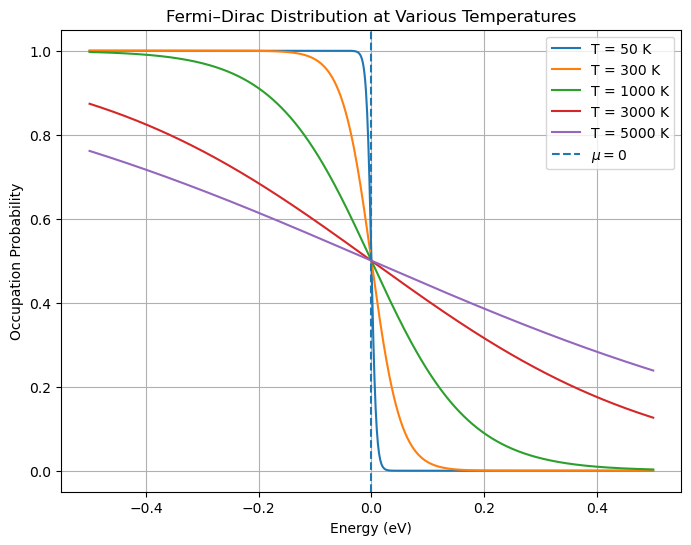

In [15]:
# Energy range (both negative and positive)
E_range = np.linspace(-0.5, 0.5, 1000)  # eV

# Temperatures to plot
temperatures = [50, 300, 1000, 3000, 5000]  # Kelvin


# Plot
plt.figure(figsize=(8, 6))

for T in temperatures:
    f = Fermi_Dirac_eV(E_range, T)
    plt.plot(E_range, f, label=f"T = {T} K")

# Formatting
plt.axvline(linestyle='--', label=r'$\mu = 0$')
plt.xlabel("Energy (eV)")
plt.ylabel("Occupation Probability")
plt.title("Fermi–Dirac Distribution at Various Temperatures")
plt.legend()
plt.grid(True)

plt.show()

# Blackbody Radiation

Plot showing the difference between the classically predicted Rayleigh-Jeans spectrum and Plank's spectrum

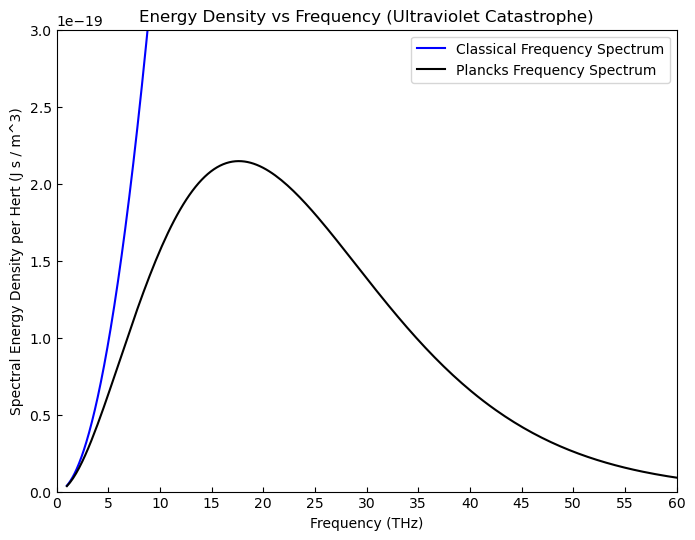

In [9]:
T = 300 #Kelvin
k = const.k #Boltzmann constant
c = const.c
h = const.h

def Classical_Spectrum(v):
    return (8 * np.pi * k * T * (v ** 2)) / (c ** 3)

def Planck_Spectrum(v):
    return ((8 * np.pi * h * (v ** 3)) / (c ** 3)) / (np.expm1((h * v) / (k * T)))

freq_planck_THz = np.linspace(1, 60, 200)
freq_classic_THz = np.linspace(1, 8.8, 200)

y_vals_classic = Classical_Spectrum(freq_classic_THz * 1e12)
y_vals_planck = Planck_Spectrum(freq_planck_THz * 1e12)

plt.figure(figsize = (8, 6))
plt.plot(freq_classic_THz, y_vals_classic, label='Classical Frequency Spectrum', color='b')
plt.plot(freq_planck_THz, y_vals_planck, label='Plancks Frequency Spectrum', color='k')
plt.xlabel("Frequency (THz)")
plt.ylabel("Spectral Energy Density per Hert (J s / m^3)")
plt.title("Energy Density vs Frequency (Ultraviolet Catastrophe)")
plt.legend()
plt.xticks(np.arange(0, 61, 5))
plt.xlim(0, 60)
plt.ylim(0, 3e-19)
plt.tick_params(axis='both', direction='in')
plt.show()

The Ultraviolete Catastrophe was solved by Max Planck when he realized he could quantize the energy light waves inside a cavity could have by making their allowed energy levels proportional to their velocity. The following demonstrates how the size of $\Delta E$ affected the average energy of a standing electromagnetic wave $E_w$ as when $\Delta E \rightarrow 0 \hspace{0.15cm} E_w = \text{kT}$  

In [8]:
#list of different energies we will look at (mulitples of kT)
delta_energies = [5, 3, 1, 0.5, 0.2, 0.01, 0.001]

def Calc_Ew(Delta_E):
    weighted_energy_sum = 0.0
    partition_sum = 1.0
    Ew = weighted_energy_sum / partition_sum
    n = 1
    while True:
        weighted_energy_sum += n * Delta_E * np.exp(-n * Delta_E)
        partition_sum += np.exp(-n * Delta_E)

        if (Ew / (weighted_energy_sum / partition_sum)) > 0.999999:
            Ew = weighted_energy_sum / partition_sum
            break
        Ew = weighted_energy_sum / partition_sum
        n += 1
    return Ew

for E in delta_energies:
    print(f"When Delta E is {E}kT, Ew = {Calc_Ew(E):0.3f}")

When Delta E is 5kT, Ew = 0.034
When Delta E is 3kT, Ew = 0.157
When Delta E is 1kT, Ew = 0.582
When Delta E is 0.5kT, Ew = 0.771
When Delta E is 0.2kT, Ew = 0.903
When Delta E is 0.01kT, Ew = 0.995
When Delta E is 0.001kT, Ew = 0.998


Replacing an integral with discrete sums can be visualized with Riemann sums. Below is a continuous graph of $E_w = Ee^{-E/(k_BT)}$ and a Riemann sum using $\Delta E = 10^{-21}$ J. At low frequencies $\Delta E$ is small and so the discreme sum closely resembles the integral which in turn means it closely follows the classically predicted resutls. As frequency increases, the spacing between allowed energies increases, thus fewer energy stats rae accessible and higher-energy states are strongly suppressed by the Boltzmann factor.

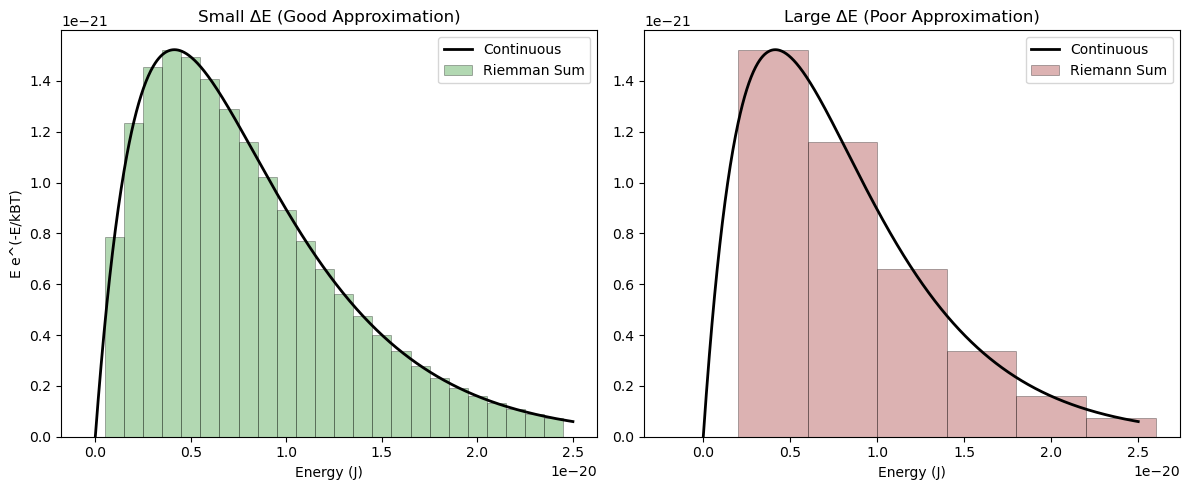

In [11]:
# Constants
kB = 1.38e-23
T = 300
kBT = kB * T

# Function
def f(E):
    return E * np.exp(-E / kBT)

# Continuous curve
E_cont = np.linspace(0, 2.5e-20, 1000)
y_cont = f(E_cont)

# Two spacings
delta_E1 = 1e-21
delta_E2 = 4e-21

# Create figure
fig, axes = plt.subplots(1, 2, figsize=(12,5))

# ---------- Plot 1: small spacing ----------
E_r1 = np.arange(0, 2.5e-20, delta_E1)

axes[0].plot(E_cont, y_cont, linewidth=2, label="Continuous", color='k')
axes[0].bar(
    E_r1,
    f(E_r1),
    width=delta_E1,
    alpha=0.3,
    edgecolor='black',
    linewidth=0.7,
    color='g',
    label='Riemman Sum'
)

axes[0].set_title("Small ΔE (Good Approximation)")
axes[0].set_xlabel("Energy (J)")
axes[0].set_ylabel("E e^(-E/kBT)")
axes[0].legend()

# ---------- Plot 2: larger spacing ----------
E_r2 = np.arange(0, 2.5e-20, delta_E2)

axes[1].plot(E_cont, y_cont, linewidth=2, label="Continuous", color='k')
axes[1].bar(
    E_r2,
    f(E_r2),
    width=delta_E2,
    alpha=0.3,
    edgecolor='black',
    linewidth=0.7,
    color='darkred',
    label='Riemann Sum'
)

axes[1].set_title("Large ΔE (Poor Approximation)")
axes[1].set_xlabel("Energy (J)")
axes[1].legend()

plt.tight_layout()
plt.show()

The following code shows where Planck's spectrum deviates from the classical spectrum and what the total energy density for all frequencies inside the cavity are at T = 300 K.

In [56]:
T = 300 #Kelvin

def Classical_Spectrum(v):
    return (8 * np.pi * k * T * (v ** 2)) / (c ** 3)

def Planck_Spectrum(v):
    return ((8 * np.pi * h * (v ** 3)) / (c ** 3)) / (np.expm1((h * v) / (k * T)))

print(f"Energy density of classical spectrum from 0 to 10^8 Hz: ρ = {quad(Classical_Spectrum, 0, 1e8)[0]:.3e} J/m^3")
print(f"Energy density of Planck's spectrum from 0 to 10^8 Hz: ρ = {quad(Planck_Spectrum, 0, 1e8)[0]:.3e} J/m^3")

print(f"\nEnergy density of classical spectrum from 10^8 to 10^13 Hz: ρ = {quad(Classical_Spectrum, 1e8, 1e13)[0]:.3e} J/m^3")
print(f"Energy density of Planck's spectrum from 10^8 to 10^13 Hz: ρ = {quad(Planck_Spectrum, 1e8, 1e13)[0]:.3e} J/m^3")

print(f"\nEnergy density of classical spectrum from 10^13 to 10^15 Hz: ρ = {quad(Classical_Spectrum, 1e13, 1e15)[0]:.4} J/m^3")
print(f"Energy density of Planck's spectrum from 10^13 to 10^15 Hz: ρ = {quad(Planck_Spectrum, 1e13, 1e15)[0]:.3e} J/m^3")
#In order to increase the stability of integrating the Planck_spectrum a change of veriables is used to calculate it.
#Integrating anything larger than e^709 will cause floating-point overflow errors, so the integral is slightly changed to avoid that.
def Planck_Integrand(x):
    if x < 700:
        return x**3 / np.expm1(x)
    else:
        return x**3 * np.exp(-x)

print(f"\nTotal energy density in the cavity: ρ = {((8 * np.pi * (k * T)**4) / (c**3 * h**3)) * quad(Planck_Integrand, 0, np.inf)[0]:0.3e}")

Energy density of classical spectrum from 0 to 10^8 Hz: ρ = 1.288e-21 J/m^3
Energy density of Planck's spectrum from 0 to 10^8 Hz: ρ = 1.288e-21 J/m^3

Energy density of classical spectrum from 10^8 to 10^13 Hz: ρ = 1.288e-06 J/m^3
Energy density of Planck's spectrum from 10^8 to 10^13 Hz: ρ = 6.753e-07 J/m^3

Energy density of classical spectrum from 10^13 to 10^15 Hz: ρ = 1.288 J/m^3
Energy density of Planck's spectrum from 10^13 to 10^15 Hz: ρ = 5.453e-06 J/m^3

Total energy density in the cavity: ρ = 6.128e-06


The sun is also a blackbody, so it will radiate according to Planck's spectrum. We can see what fraction of the emited light is within the visible range for both the core of sun and the surface.

In [74]:
T = 2e6 # Temp in Kelvin of core of the sun
total_core_density = ((8 * np.pi * (k * T)**4) / (c**3 * h**3)) * quad(Planck_Integrand, 0, np.inf)[0]
print(f"Total energy density in core of the sun: ρ = {total_core_density:0.3e}")

visible_spectrum_core = quad(Planck_Spectrum, 3.84e14, 7.69e14)[0]
print(f"{(visible_spectrum_core / total_core_density) * 100.0:0.6f}% of energy desnity in the core of the sun is within the visible range")

T = 6000 # Temp in Kelvin at surface of sun
total_surface_density = ((8 * np.pi * (k * T)**4) / (c**3 * h**3)) * quad(Planck_Integrand, 0, np.inf)[0]
print(f"\nTotal energy density on the surface of the sun: ρ = {total_surface_density:0.3e}")

visible_spectrum_surface = quad(Planck_Spectrum, 3.84e14, 7.69e14)[0]
print(f"\n{(visible_spectrum_core / total_core_density) * 100.0:0.6f}% of energy desnity in the core of the sun is within the visible range")

Total energy density in core of the sun: ρ = 1.211e+10

0.000028% of energy desnity in the core of the sun is within the visible range
